# ⚙️ Hyperparameter Tuning — LightGBM avec Optuna
**Projet Marketing Data** · M2 Data Engineering · Paris Ynov Campus

Ce notebook optimise automatiquement les hyperparamètres du modèle LightGBM
via une recherche bayésienne (Optuna). L'objectif est de maximiser l'AUC-ROC
en cross-validation 5-fold.

## Pourquoi Optuna plutôt qu'une GridSearch ?

| Méthode | Approche | Nb essais nécessaires |
|---------|----------|----------------------|
| **GridSearch** | Teste toutes les combinaisons | Exponentiel (lent) |
| **RandomSearch** | Tire aléatoirement | Linéaire (peu efficace) |
| **Optuna (TPE)** | Apprend des essais précédents | Sous-linéaire (efficace) |

Optuna utilise l'algorithme **TPE (Tree-structured Parzen Estimator)** :
chaque essai informe le suivant, ce qui converge beaucoup plus vite vers l'optimum.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
import os
sys.path.append('..')
os.chdir('..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

from src.load import query_sqlite

# Désactive les logs Optuna pour un affichage plus propre
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')

print('✅ Imports OK — Optuna', optuna.__version__)

✅ Imports OK — Optuna 4.8.0


## 1. Chargement et préparation des données

In [2]:
# ── Chargement des features depuis SQLite ─────────────────────────────────────
sql = """
    SELECT
        c.client_id, c.age, c.segment, c.region, c.anciennete_mois,
        t_agg.n_touches, t_agg.first_canal, t_agg.last_canal, t_agg.converti,
        t_agg.duree_parcours_jours, t_agg.nb_canaux_distincts, t_agg.ratio_canaux_payants
    FROM clients c
    JOIN (
        SELECT
            client_id,
            MAX(n_touches_total)                              AS n_touches,
            MAX(CASE WHEN is_first_touch = 1 THEN canal END) AS first_canal,
            MAX(CASE WHEN is_last_touch  = 1 THEN canal END) AS last_canal,
            MAX(converti)                                     AS converti,
            CAST((JULIANDAY(MAX(date)) - JULIANDAY(MIN(date))) AS INTEGER) AS duree_parcours_jours,
            COUNT(DISTINCT canal)                             AS nb_canaux_distincts,
            ROUND(SUM(CASE WHEN canal IN ('Google Ads', 'Facebook', 'Instagram')
                THEN 1.0 ELSE 0.0 END) / COUNT(*), 3)        AS ratio_canaux_payants
        FROM touchpoints GROUP BY client_id
    ) t_agg ON c.client_id = t_agg.client_id
"""

df = query_sqlite(sql)

# Preprocessing
cat_cols = ['segment', 'region', 'first_canal', 'last_canal']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

feature_cols = [
    'age', 'segment', 'region', 'anciennete_mois', 'n_touches',
    'first_canal', 'last_canal', 'duree_parcours_jours',
    'nb_canaux_distincts', 'ratio_canaux_payants',
]

X = df[feature_cols]
y = df['converti']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'✅ Données prêtes — {X.shape[0]:,} clients, {X.shape[1]} features')
print(f'   scale_pos_weight : {scale_pos_weight:.2f}')

✅ Données prêtes — 50,000 clients, 10 features
   scale_pos_weight : 2.40


## 2. Paramètres de base (avant tuning)

In [3]:
# ── AUC de référence avec les paramètres actuels de model.py ─────────────────
baseline_model = LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = cross_val_score(
    baseline_model, X_train, y_train, cv=cv, scoring='roc_auc'
)

print(f'📊 AUC baseline (paramètres actuels) :')
print(f'   Scores : {[round(s, 4) for s in baseline_scores]}')
print(f'   Moyenne : {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}')

📊 AUC baseline (paramètres actuels) :
   Scores : [0.7619, 0.7587, 0.7719, 0.7649, 0.7738]
   Moyenne : 0.7663 ± 0.0058


## 3. Optimisation Optuna (50 essais)

In [4]:
# ── Fonction objectif : Optuna cherche à maximiser cette valeur ───────────────
def objective(trial) -> float:
    """
    Fonction objectif pour Optuna.
    Chaque appel teste une combinaison de paramètres et retourne l'AUC CV.
    Optuna apprend des résultats précédents pour proposer de meilleures combinaisons.
    """
    params = {
        # Nombre d'arbres : plus = meilleur mais plus lent
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        # Profondeur max : contrôle la complexité du modèle
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        # Taux d'apprentissage : plus petit = plus précis mais plus lent
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        # Fraction des données utilisées par arbre (régularisation)
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        # Fraction des features utilisées par arbre (régularisation)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # Régularisation L1 : réduit les poids inutiles
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        # Régularisation L2 : lisse les poids
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        # Nombre minimum d'échantillons par feuille
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        # Paramètres fixes
        'scale_pos_weight': scale_pos_weight,
        'random_state':    42,
        'n_jobs':          -1,
        'verbose':         -1,
    }

    model = LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    return scores.mean()


# ── Lancement de l'optimisation ───────────────────────────────────────────────
print('🔍 Démarrage de l\'optimisation Optuna (50 essais)...')
print('   Cela peut prendre 3-5 minutes.\n')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Optimisation terminée !')
print(f'   Meilleure AUC CV : {study.best_value:.4f}')
print(f'   Meilleurs paramètres :')
for k, v in study.best_params.items():
    print(f'     {k}: {v}')

🔍 Démarrage de l'optimisation Optuna (50 essais)...
   Cela peut prendre 3-5 minutes.



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optimisation terminée !
   Meilleure AUC CV : 0.7708
   Meilleurs paramètres :
     n_estimators: 250
     max_depth: 3
     learning_rate: 0.04298837872440844
     subsample: 0.7403917167449877
     colsample_bytree: 0.8495399714987796
     reg_alpha: 0.0015185015465000221
     reg_lambda: 0.014123109598036972
     min_child_samples: 98


## 4. Comparaison baseline vs tuné

In [5]:
# ── Entraînement du modèle tuné et comparaison ────────────────────────────────
best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
})

tuned_model = LGBMClassifier(**best_params)
tuned_scores = cross_val_score(
    tuned_model, X_train, y_train, cv=cv, scoring='roc_auc'
)

print('📊 Comparaison baseline vs modèle tuné :')
print(f'   Baseline : {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}')
print(f'   Tuné     : {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}')
gain = (tuned_scores.mean() - baseline_scores.mean()) * 100
print(f'   Gain     : {gain:+.2f} points AUC')

📊 Comparaison baseline vs modèle tuné :
   Baseline : 0.7663 ± 0.0058
   Tuné     : 0.7708 ± 0.0045
   Gain     : +0.46 points AUC


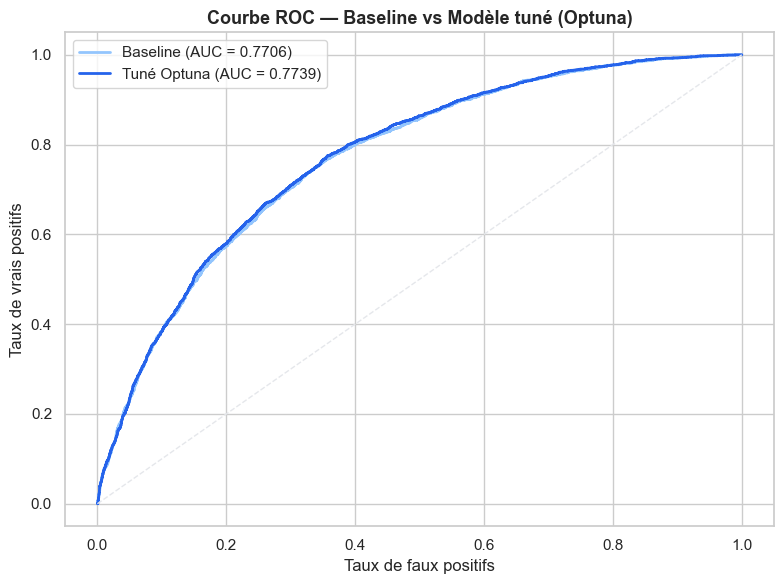

✅ optuna_roc_comparison.png sauvegardé


In [6]:
# ── Courbes ROC : baseline vs tuné ───────────────────────────────────────────
baseline_model.fit(X_train, y_train)
tuned_model.fit(X_train, y_train)

y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]
y_proba_tuned    = tuned_model.predict_proba(X_test)[:, 1]

auc_baseline = roc_auc_score(y_test, y_proba_baseline)
auc_tuned    = roc_auc_score(y_test, y_proba_tuned)

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_baseline)
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_b, tpr_b, color='#93C5FD', linewidth=2,
        label=f'Baseline (AUC = {auc_baseline:.4f})')
ax.plot(fpr_t, tpr_t, color='#2563EB', linewidth=2,
        label=f'Tuné Optuna (AUC = {auc_tuned:.4f})')
ax.plot([0, 1], [0, 1], color='#E5E7EB', linestyle='--', linewidth=1)
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbe ROC — Baseline vs Modèle tuné (Optuna)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/optuna_roc_comparison.png', dpi=150)
plt.show()
print('✅ optuna_roc_comparison.png sauvegardé')

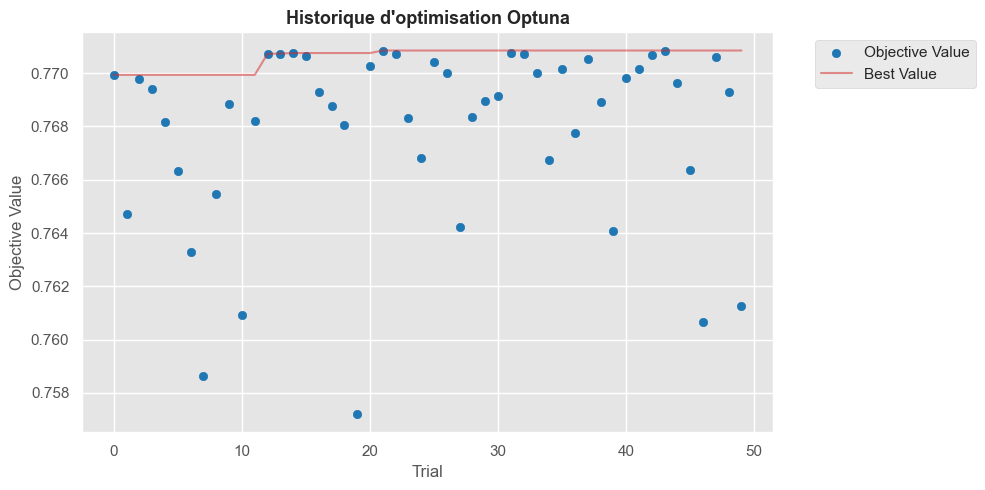

✅ optuna_history.png sauvegardé


In [9]:
# ── Historique d'optimisation Optuna ─────────────────────────────────────────
ax = optuna.visualization.matplotlib.plot_optimization_history(study)
ax.set_title('Historique d\'optimisation Optuna', fontsize=13, fontweight='bold')
ax.figure.set_size_inches(10, 5)
plt.tight_layout()
plt.savefig('outputs/optuna_history.png', dpi=150)
plt.show()
print('✅ optuna_history.png sauvegardé')

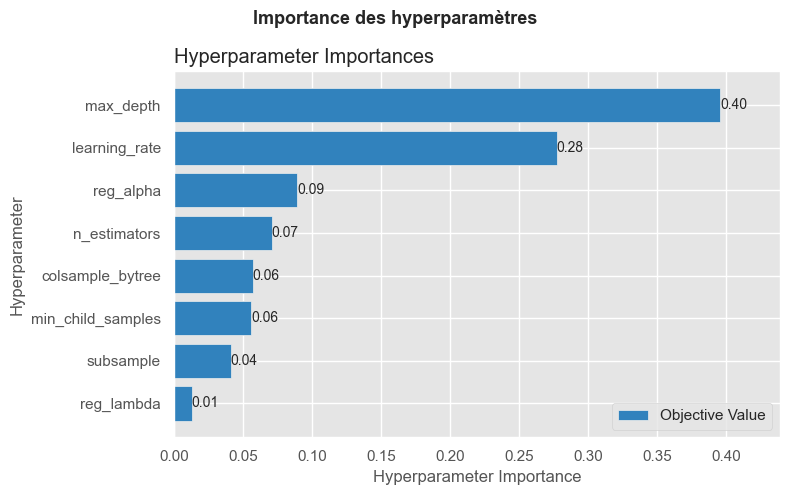

✅ optuna_param_importance.png sauvegardé


In [11]:
# ── Importance des hyperparamètres ────────────────────────────────────────────
ax = optuna.visualization.matplotlib.plot_param_importances(study)
ax.set_title('')  # supprime le titre Optuna
ax.figure.set_size_inches(8, 5)
ax.figure.suptitle('Importance des hyperparamètres', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/optuna_param_importance.png', dpi=150)
plt.show()
print('✅ optuna_param_importance.png sauvegardé')

## 5. Meilleurs paramètres à copier dans model.py

In [12]:
# ── Génère le bloc de code à copier dans model.py ────────────────────────────
print('📋 Copie ce bloc dans train_model() de src/model.py :\n')
print('model = LGBMClassifier(')
for k, v in study.best_params.items():
    if isinstance(v, float):
        print(f'    {k}={v:.6f},')
    else:
        print(f'    {k}={v},')
print('    scale_pos_weight=scale_pos_weight,')
print('    random_state=42,')
print('    n_jobs=-1,')
print('    verbose=-1,')
print(')')
print(f'\n# AUC CV attendue : {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}')
print(f'# AUC test set    : {auc_tuned:.4f}')

📋 Copie ce bloc dans train_model() de src/model.py :

model = LGBMClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.042988,
    subsample=0.740392,
    colsample_bytree=0.849540,
    reg_alpha=0.001519,
    reg_lambda=0.014123,
    min_child_samples=98,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# AUC CV attendue : 0.7708 ± 0.0045
# AUC test set    : 0.7739
